In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import VAR
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import shap

C:\Users\user\Zadanie_Rekrutacyjne2024\Zadanie_Rekrutacyjne2024\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import warnings 
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_excel('dane_2010plus.xlsx')
df['rok_miesiac'] = pd.to_datetime(df['rok_miesiac'], format='%Y%m')
df.set_index('rok_miesiac', inplace=True)

### Badanie stacjonarności

In [26]:
# Sprawdzenie stacjonarności szeregów czasowych
def test_stacjonarnosci(df):
    wynik = adfuller(df)
    print(f'Statystyka ADF: {wynik[0]}')
    print(f'P-value: {wynik[1]}')
    print(f'Wartości krytyczne: {wynik[4]}')
    if wynik[1] <= 0.05:
        print("Szereg jest stacjonarny")
    else:
        print("Szereg nie jest stacjonarny")

In [27]:
test_stacjonarnosci(df['stopa_bezrobocia'])

Statystyka ADF: -1.4234145794904554
P-value: 0.571000834025678
Wartości krytyczne: {'1%': np.float64(-3.470616369591229), '5%': np.float64(-2.8792214018977655), '10%': np.float64(-2.57619681359045)}
Szereg nie jest stacjonarny


In [28]:
test_stacjonarnosci(df['stopa_bezrobocia'].diff().dropna())

Statystyka ADF: -2.219845299103094
P-value: 0.19912175853140157
Wartości krytyczne: {'1%': np.float64(-3.470616369591229), '5%': np.float64(-2.8792214018977655), '10%': np.float64(-2.57619681359045)}
Szereg nie jest stacjonarny


In [30]:
test_stacjonarnosci(df['stopa_bezrobocia'].diff().diff().dropna())

Statystyka ADF: -4.9160835077721154
P-value: 3.244569918518262e-05
Wartości krytyczne: {'1%': np.float64(-3.470616369591229), '5%': np.float64(-2.8792214018977655), '10%': np.float64(-2.57619681359045)}
Szereg jest stacjonarny


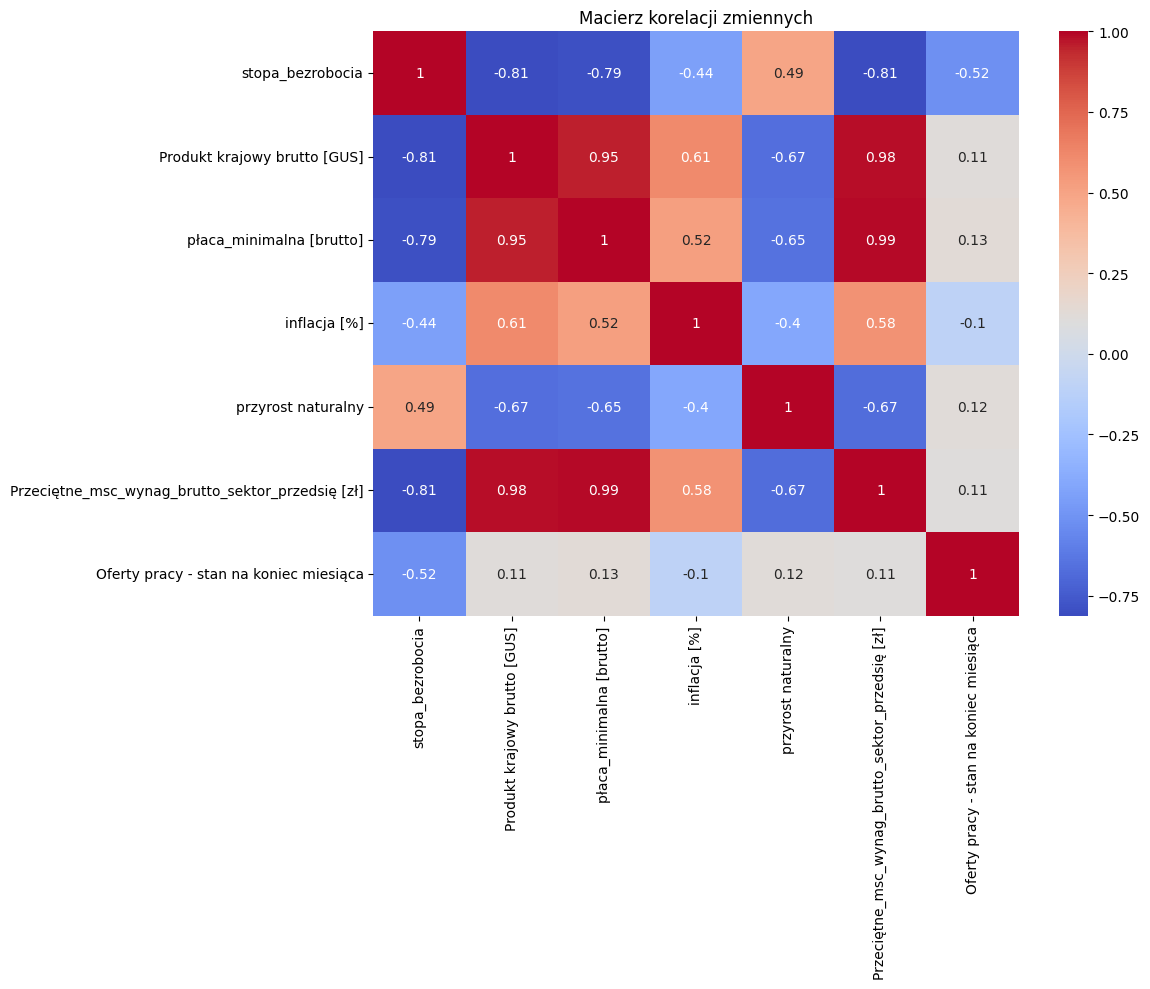

In [7]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Macierz korelacji zmiennych')
plt.tight_layout()
plt.show()

### Model regresji liniowej

In [9]:
X = df[['inflacja [%]', 'Produkt krajowy brutto [GUS]', 'płaca_minimalna [brutto]', 'przyrost naturalny', 
        'Przeciętne_msc_wynag_brutto_sektor_przedsię [zł]', 'Oferty pracy - stan na koniec miesiąca']]
X = sm.add_constant(X)  # Dodanie stałej do modelu

# Zmienna objaśniana
y = df['stopa_bezrobocia']

In [10]:
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       stopa_bezrobocia   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.848
Method:                 Least Squares   F-statistic:                     166.9
Date:                Tue, 29 Apr 2025   Prob (F-statistic):           3.22e-69
Time:                        20:36:28   Log-Likelihood:                -293.30
No. Observations:                 180   AIC:                             600.6
Df Residuals:                     173   BIC:                             623.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

#### Testy diagnostyczne

*Test heteroskedastyczności*

In [11]:
from statsmodels.stats.diagnostic import het_breuschpagan
bp_test = het_breuschpagan(model.resid, model.model.exog)
print(f"Test Breusch-Pagan p-value: {bp_test[1]}")

Test Breusch-Pagan p-value: 0.1403860424952215


*Test autokorelacji*

In [12]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(model.resid, lags=12)

# Wydrukuj p-value dla każdego laga (albo tylko dla ostatniego)
print(f"Test Ljung-Box na 12 opóźnieniach p-value: {lb_test['lb_pvalue'].iloc[-1]}")

Test Ljung-Box na 12 opóźnieniach p-value: 1.8009740255288893e-231


### Model z opóźnionymi zmiennymi

#### Inżynieria cech (feature engineering)

In [14]:
lags = 12
df_lags = df.copy()

for var in ['Produkt krajowy brutto [GUS]','płaca_minimalna [brutto]', 'inflacja [%]', 'przyrost naturalny','Przeciętne_msc_wynag_brutto_sektor_przedsię [zł]', 'Oferty pracy - stan na koniec miesiąca']:
    for i in range(1, lags+1):
        df_lags[f'{var}_lag{i}'] = df_lags[var].shift(i)

# Usunięcie wierszy z NaN (powstałych przez przesunięcia)
df_lags = df_lags.dropna()

In [15]:
# Model z opóźnieniami
X_lags = df_lags.drop(columns=['stopa_bezrobocia'])
X_lags = sm.add_constant(X_lags)
y_lags = df_lags['stopa_bezrobocia']

model_lags = sm.OLS(y_lags, X_lags).fit()
print(model_lags.summary())

                            OLS Regression Results                            
Dep. Variable:       stopa_bezrobocia   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.962
Method:                 Least Squares   F-statistic:                     54.97
Date:                Tue, 29 Apr 2025   Prob (F-statistic):           1.13e-52
Time:                        20:36:46   Log-Likelihood:                -105.63
No. Observations:                 168   AIC:                             369.3
Df Residuals:                      89   BIC:                             616.0
Df Model:                          78                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

### Model ARIMA

#### Test ACF i PACF do identyfikacji parametrów

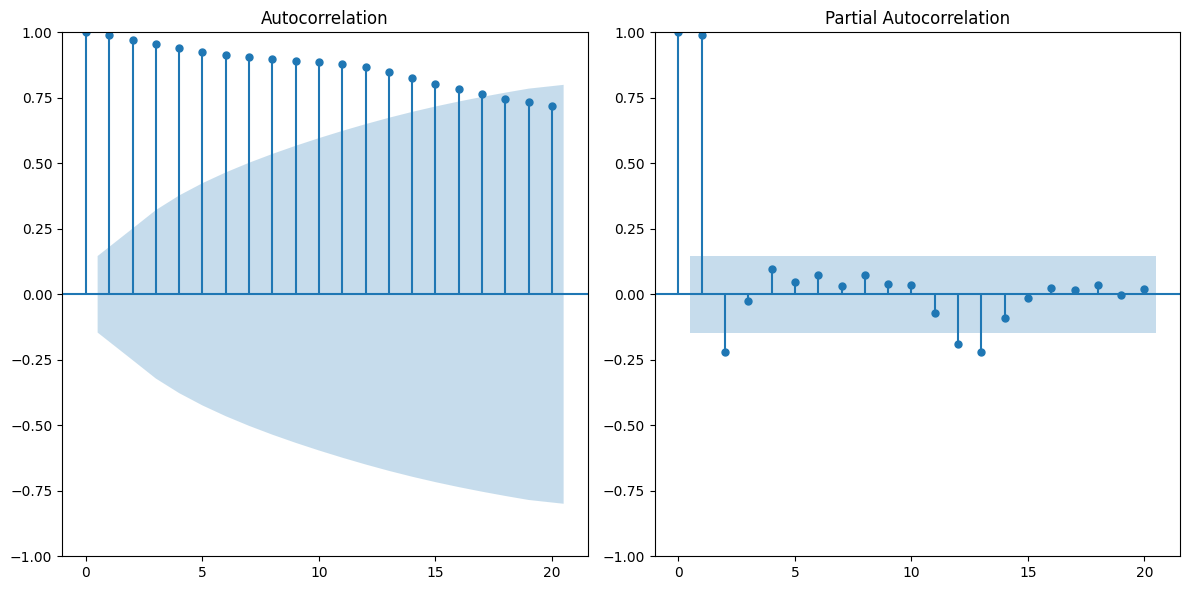

In [23]:
plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_acf(df['stopa_bezrobocia'].dropna(), ax=plt.gca(), lags=20)
plt.subplot(122)
plot_pacf(df['stopa_bezrobocia'].dropna(), ax=plt.gca(), lags=20)
plt.tight_layout()
plt.show()

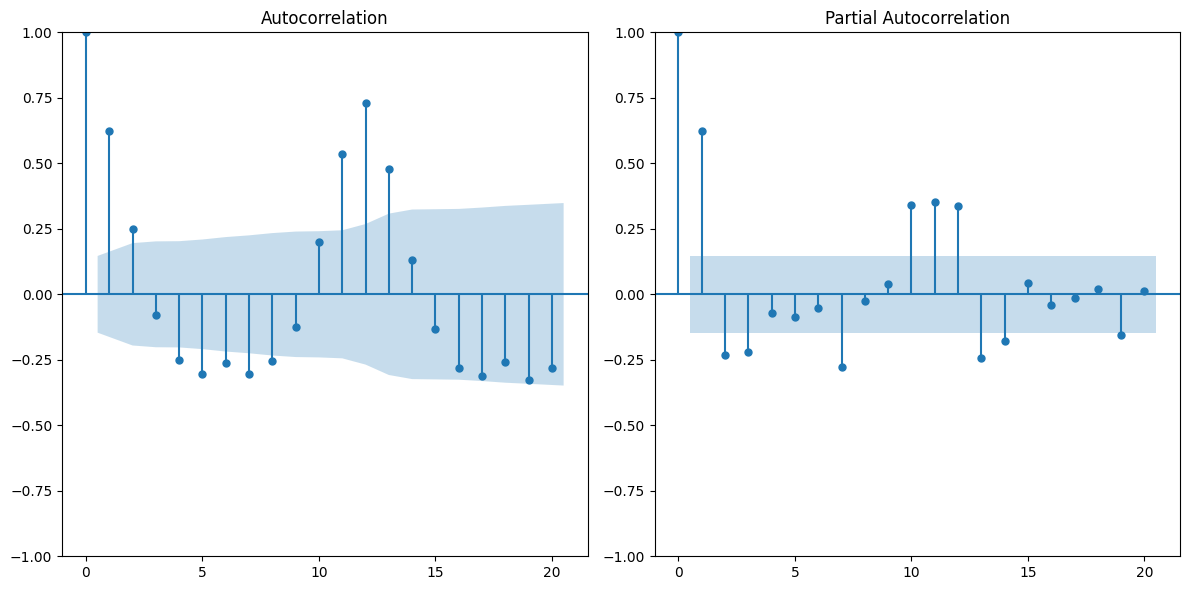

In [24]:
plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_acf(df['stopa_bezrobocia'].diff().dropna(), ax=plt.gca(), lags=20)
plt.subplot(122)
plot_pacf(df['stopa_bezrobocia'].diff().dropna(), ax=plt.gca(), lags=20)
plt.tight_layout()
plt.show()

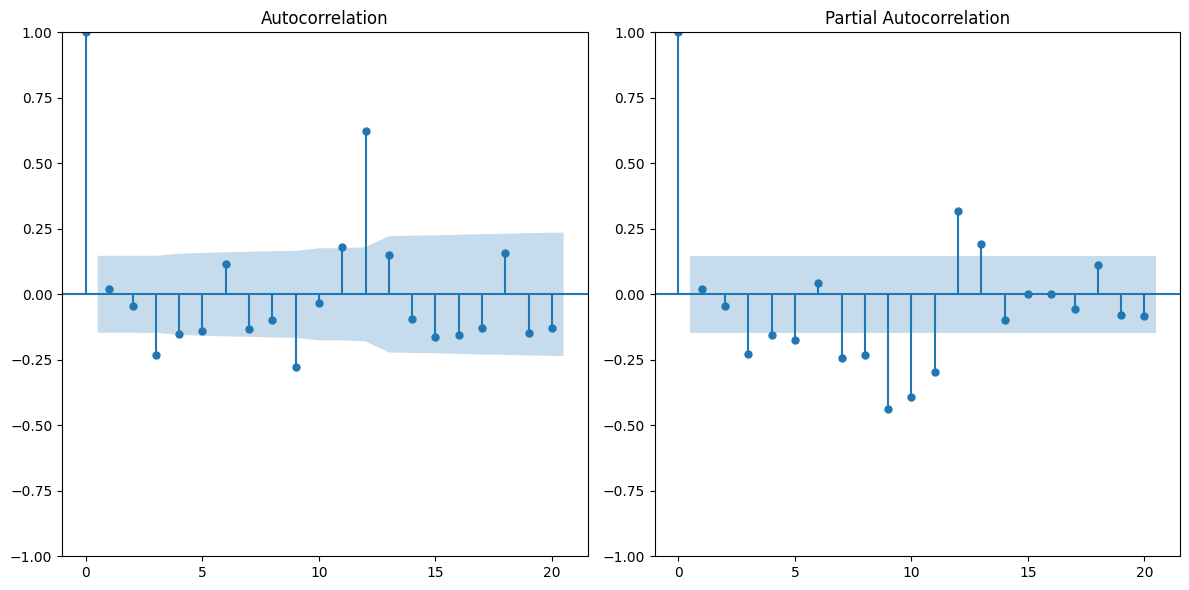

In [18]:
plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_acf(df['stopa_bezrobocia'].diff().diff().dropna(), ax=plt.gca(), lags=20)
plt.subplot(122)
plot_pacf(df['stopa_bezrobocia'].diff().diff().dropna(), ax=plt.gca(), lags=20)
plt.tight_layout()
plt.show()

### Test przyczynowości Grangera

In [17]:
max_lag = 12
variables = ['Produkt krajowy brutto [GUS]','płaca_minimalna [brutto]', 'inflacja [%]', 'przyrost naturalny','Przeciętne_msc_wynag_brutto_sektor_przedsię [zł]', 'Oferty pracy - stan na koniec miesiąca']

for i in variables:
    for j in variables:
        if i != j:
            print(f"\nTest przyczynowości Grangera: {j} -> {i}")
            granger_test = grangercausalitytests(df[[i, j]].dropna(), maxlag=max_lag, verbose=False)
            for lag in range(1, max_lag+1):
                print(f"Lag {lag}: p-value = {granger_test[lag][0]['ssr_chi2test'][1]}")


Test przyczynowości Grangera: płaca_minimalna [brutto] -> Produkt krajowy brutto [GUS]
Lag 1: p-value = 5.353140355712725e-07
Lag 2: p-value = 2.6508840903166426e-07
Lag 3: p-value = 2.6750751170083818e-08
Lag 4: p-value = 4.5732055507716975e-05
Lag 5: p-value = 3.5662068682221443e-06
Lag 6: p-value = 1.0350254018269068e-08
Lag 7: p-value = 1.9582479977834632e-06
Lag 8: p-value = 1.2785211288270487e-08
Lag 9: p-value = 4.575124444337133e-14
Lag 10: p-value = 4.852062875566893e-43
Lag 11: p-value = 1.2245487646732426e-37
Lag 12: p-value = 5.155877452644817e-27

Test przyczynowości Grangera: inflacja [%] -> Produkt krajowy brutto [GUS]
Lag 1: p-value = 0.3753379780902383
Lag 2: p-value = 0.5140455452419566
Lag 3: p-value = 0.6898838639870225
Lag 4: p-value = 0.5316151087954577
Lag 5: p-value = 0.672700524444729
Lag 6: p-value = 0.7290813966166878
Lag 7: p-value = 0.7537924230349756
Lag 8: p-value = 0.8197914539519741
Lag 9: p-value = 0.8589576206976484
Lag 10: p-value = 0.19110924592236

### Model Sarima

In [18]:
exog_vars = ['Produkt krajowy brutto [GUS]','płaca_minimalna [brutto]', 'inflacja [%]', 'przyrost naturalny','Przeciętne_msc_wynag_brutto_sektor_przedsię [zł]', 'Oferty pracy - stan na koniec miesiąca']

exog = df[exog_vars]

train_size = len(df) - 24
train_data = df['stopa_bezrobocia'][:train_size]
test_data = df['stopa_bezrobocia'][train_size:]
train_exog = exog[:train_size]
test_exog = exog[train_size:]

In [19]:
def evaluate_sarimax_model(p, d, q, P, D, Q, s, endog, exogenous):
    try:
        model = SARIMAX(endog=endog, 
                       exog=exogenous,
                       order=(p, d, q), 
                       seasonal_order=(P, D, Q, s),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
        results = model.fit(disp=False)
        return results.aic, results.bic, results
    except:
        return None, None, None

In [20]:
best_aic = float('inf')
best_params = None
best_model = None

for p in [0, 1, 2]:
    for d in [0, 1]:
        for q in [0, 1]:
            for P in [0, 1]:
                for D in [0, 1]:
                    for Q in [0, 1]:
                        # Dla danych miesięcznych s=12, dla kwartalnych s=4
                        s = 12 if df.index.freq == 'M' else 4
                        print(f"Testowanie SARIMAX({p},{d},{q})x({P},{D},{Q},{s})")
                        aic, bic, model = evaluate_sarimax_model(p, d, q, P, D, Q, s, train_data, train_exog)
                        if aic is not None and aic < best_aic:
                            best_aic = aic
                            best_params = (p, d, q, P, D, Q, s)
                            best_model = model

Testowanie SARIMAX(0,0,0)x(0,0,0,4)
Testowanie SARIMAX(0,0,0)x(0,0,1,4)
Testowanie SARIMAX(0,0,0)x(0,1,0,4)
Testowanie SARIMAX(0,0,0)x(0,1,1,4)
Testowanie SARIMAX(0,0,0)x(1,0,0,4)
Testowanie SARIMAX(0,0,0)x(1,0,1,4)
Testowanie SARIMAX(0,0,0)x(1,1,0,4)
Testowanie SARIMAX(0,0,0)x(1,1,1,4)
Testowanie SARIMAX(0,0,1)x(0,0,0,4)
Testowanie SARIMAX(0,0,1)x(0,0,1,4)
Testowanie SARIMAX(0,0,1)x(0,1,0,4)
Testowanie SARIMAX(0,0,1)x(0,1,1,4)
Testowanie SARIMAX(0,0,1)x(1,0,0,4)
Testowanie SARIMAX(0,0,1)x(1,0,1,4)
Testowanie SARIMAX(0,0,1)x(1,1,0,4)
Testowanie SARIMAX(0,0,1)x(1,1,1,4)
Testowanie SARIMAX(0,1,0)x(0,0,0,4)
Testowanie SARIMAX(0,1,0)x(0,0,1,4)
Testowanie SARIMAX(0,1,0)x(0,1,0,4)
Testowanie SARIMAX(0,1,0)x(0,1,1,4)
Testowanie SARIMAX(0,1,0)x(1,0,0,4)
Testowanie SARIMAX(0,1,0)x(1,0,1,4)
Testowanie SARIMAX(0,1,0)x(1,1,0,4)
Testowanie SARIMAX(0,1,0)x(1,1,1,4)
Testowanie SARIMAX(0,1,1)x(0,0,0,4)
Testowanie SARIMAX(0,1,1)x(0,0,1,4)
Testowanie SARIMAX(0,1,1)x(0,1,0,4)
Testowanie SARIMAX(0,1,1)x(0

In [21]:
print(f"Najlepszy model SARIMAX{best_params} z AIC = {best_aic}")

Najlepszy model SARIMAX(1, 1, 1, 1, 0, 0, 4) z AIC = -64.91986517361138


In [22]:
print(best_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                   stopa_bezrobocia   No. Observations:                  156
Model:             SARIMAX(1, 1, 1)x(1, 0, [], 4)   Log Likelihood                  42.460
Date:                            Tue, 22 Apr 2025   AIC                            -64.920
Time:                                    21:26:27   BIC                            -34.814
Sample:                                01-01-2010   HQIC                           -52.689
                                     - 12-01-2022                                         
Covariance Type:                              opg                                         
                                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
Produkt krajowy brutto [GUS]          

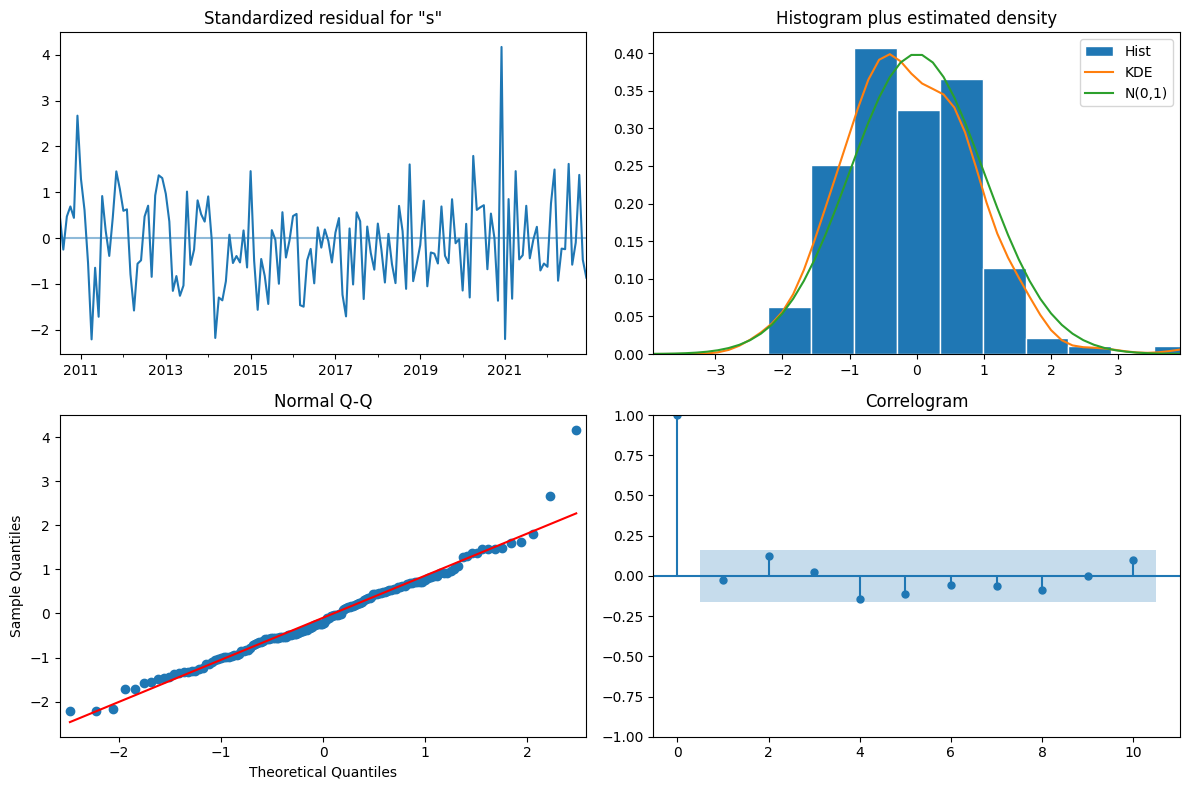

In [23]:
best_model.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [24]:
# Prognoza na zbiorze testowym
forecast = best_model.get_forecast(steps=len(test_data), exog=test_exog)
predicted_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# Ocena modelu na zbiorze testowym
mse = mean_squared_error(test_data, predicted_mean)
mae = mean_absolute_error(test_data, predicted_mean)
r2 = r2_score(test_data, predicted_mean)

In [25]:
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 3.36601242852328
Mean Absolute Error: 1.658882855851204
R^2 Score: -87.44996162542927


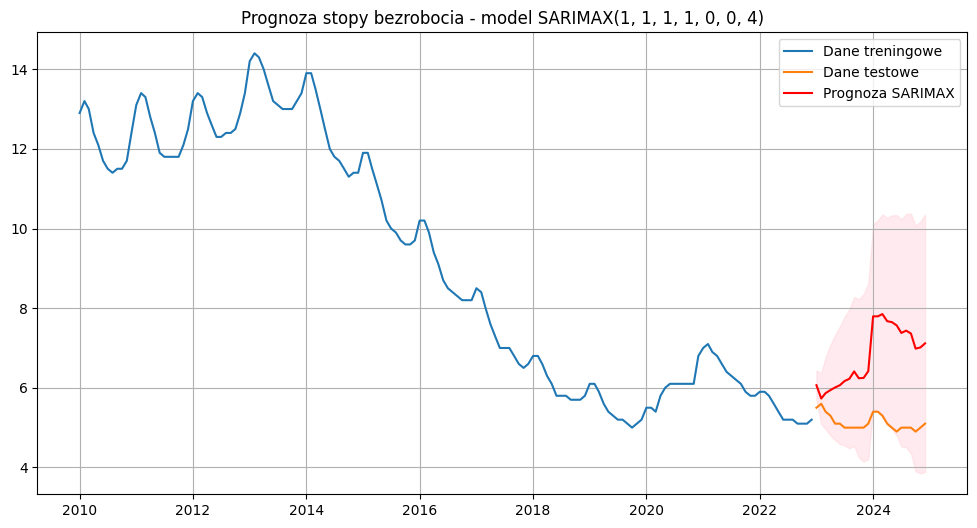

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data, label='Dane treningowe')
plt.plot(test_data.index, test_data, label='Dane testowe')
plt.plot(test_data.index, predicted_mean, label='Prognoza SARIMAX', color='red')
plt.fill_between(test_data.index, 
                 conf_int.iloc[:, 0], 
                 conf_int.iloc[:, 1], 
                 color='pink', alpha=0.3)
plt.title(f'Prognoza stopy bezrobocia - model SARIMAX{best_params}')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
print("\nWspółczynniki modelu (dla zmiennych egzogenicznych):")
coef_exog = pd.DataFrame({
    'coef': best_model.params[len(best_model.params)-len(exog_vars):],
    'pvalue': best_model.pvalues[len(best_model.pvalues)-len(exog_vars):]
})
coef_exog.index = exog_vars
print(coef_exog)


Współczynniki modelu (dla zmiennych egzogenicznych):
                                                      coef        pvalue
Produkt krajowy brutto [GUS]                     -0.000125  1.533458e-01
płaca_minimalna [brutto]                         -0.000007  6.344385e-04
inflacja [%]                                      0.646304  8.296332e-05
przyrost naturalny                               -0.222656  2.429022e-01
Przeciętne_msc_wynag_brutto_sektor_przedsię [zł] -0.197192  3.845978e-02
Oferty pracy - stan na koniec miesiąca            0.035854  9.978904e-13


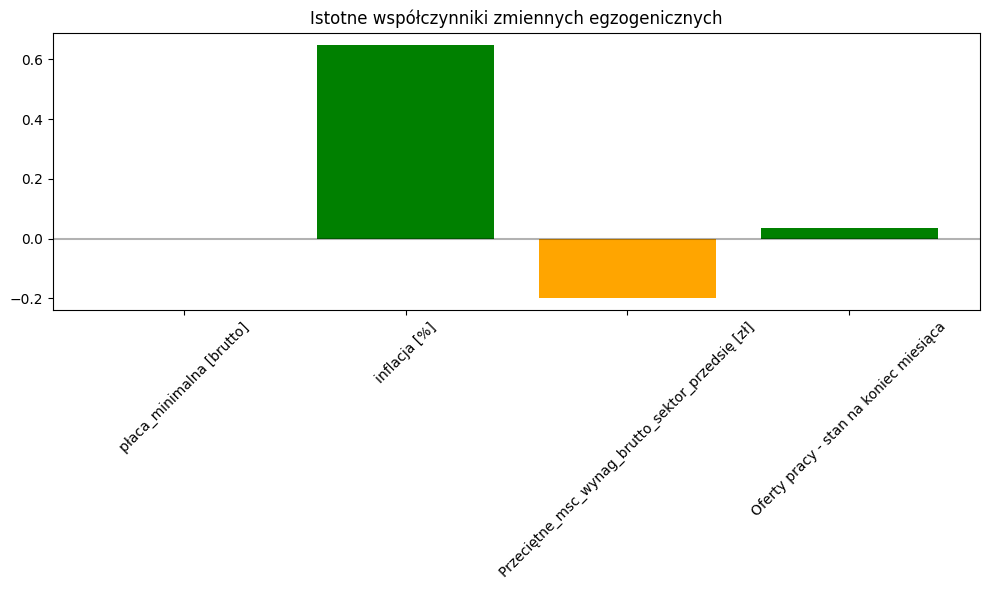

In [28]:
plt.figure(figsize=(10, 6))
significant_vars = coef_exog[coef_exog['pvalue'] < 0.05]
colors = ['green' if v < 0.01 else 'orange' for v in significant_vars['pvalue']]
plt.bar(significant_vars.index, significant_vars['coef'], color=colors)
plt.title('Istotne współczynniki zmiennych egzogenicznych')
plt.xticks(rotation=45)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

### XGBoost

#### Inżynieria cech

In [29]:
def create_features(df, target_col, lag_range=6):
    df_features = df.copy()
    
    # Dodajemy opóźnione wartości dla zmiennej celu (stopa_bezrobocia)
    for i in range(1, lag_range + 1):
        df_features[f'{target_col}_lag{i}'] = df_features[target_col].shift(i)
    
    # Dodajemy opóźnione wartości dla pozostałych zmiennych
    for col in df.columns:
        if col != target_col:
            for i in range(1, lag_range + 1):
                df_features[f'{col}_lag{i}'] = df_features[col].shift(i)
    
    # Dodajemy cechy sezonowe (dla danych miesięcznych)
    if isinstance(df.index, pd.DatetimeIndex):
        df_features['month'] = df_features.index.month
        df_features['quarter'] = df_features.index.quarter
        # Dodajemy rok jako cechę, co może być pomocne do modelowania trendów długoterminowych
        df_features['year'] = df_features.index.year
    
    return df_features

# Przygotowanie danych
target_col = 'stopa_bezrobocia'
df_with_features = create_features(df, target_col, lag_range=6)
df_with_features = df_with_features.dropna()  # Usuwamy wiersze z NaN (powstałe przez przesunięcia)

#### Podział na dane testowe i treningowe

In [30]:
# Podział na zbiór treningowy i testowy - uwaga na chronologię danych
# Użycie testu na ostatnich 20% danych
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

In [31]:
X_train.columns = X_train.columns.str.replace(r'[\[\]<>]', '', regex=True)
X_test.columns = X_test.columns.str.replace(r'[\[\]<>]', '', regex=True)

In [32]:
xgb_model = XGBRegressor(
    objective='reg:squarederror', 
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Trenowanie modelu
xgb_model.fit(X_train, y_train)

# Predykcja
y_pred = xgb_model.predict(X_test)

# Ocena modelu
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 0.7270022251975753
Mean Absolute Error: 0.7714341640472413
R^2 Score: -9.158435405456142


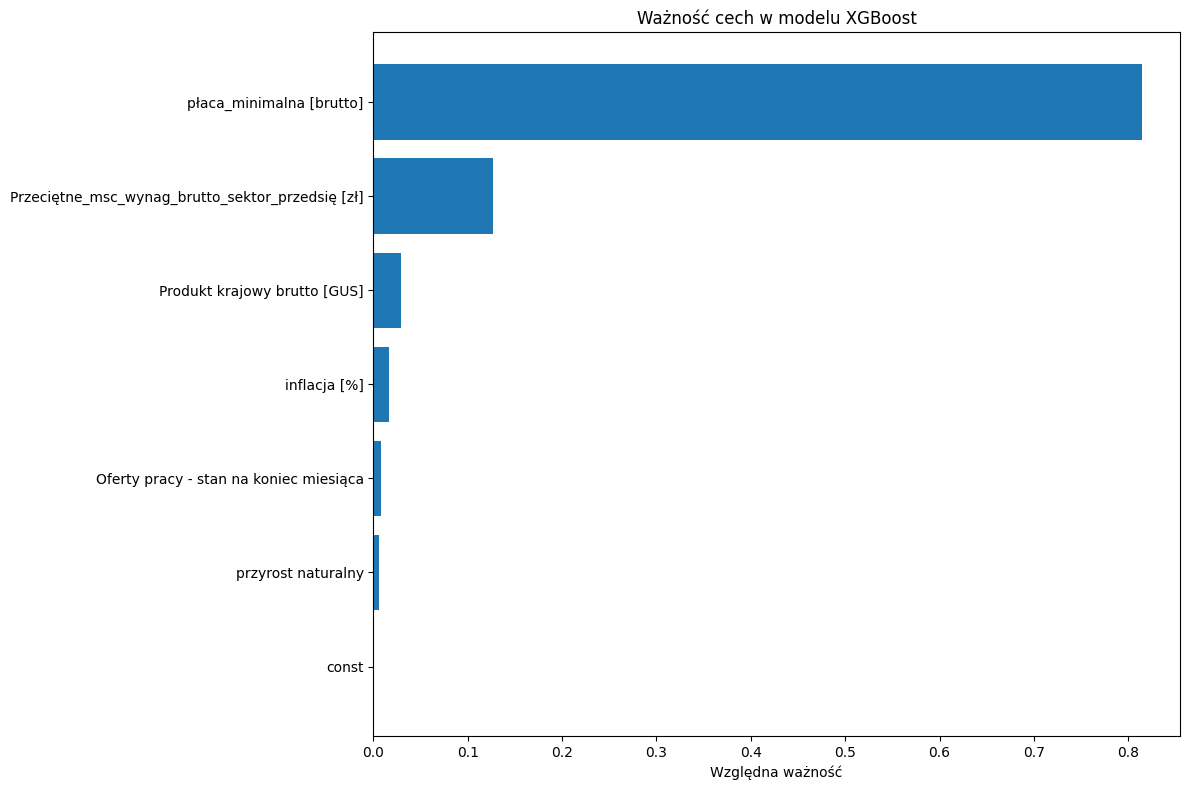

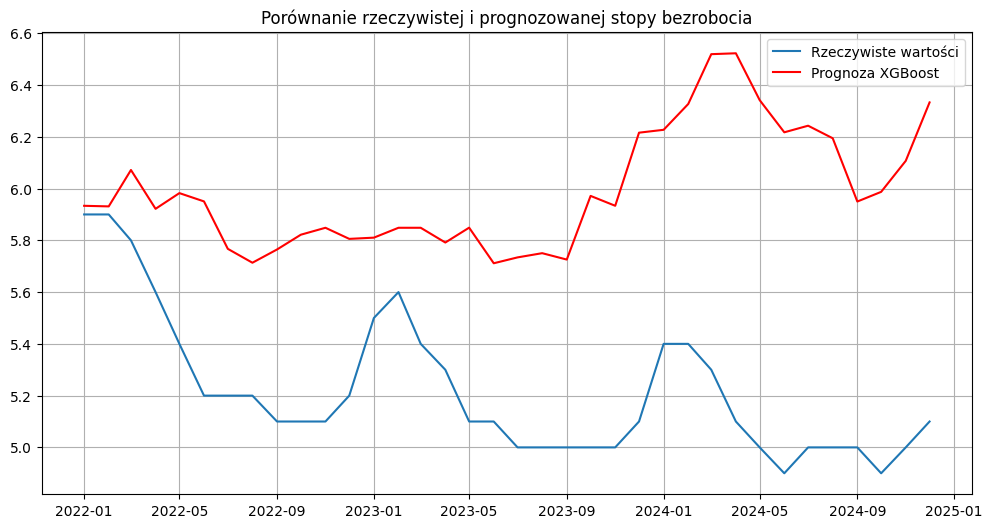

In [33]:
plt.figure(figsize=(12, 8))
sorted_idx = np.argsort(xgb_model.feature_importances_)
plt.barh(np.array(X.columns)[sorted_idx], xgb_model.feature_importances_[sorted_idx])
plt.title('Ważność cech w modelu XGBoost')
plt.xlabel('Względna ważność')
plt.tight_layout()
plt.show()

# Wizualizacja rzeczywistych i prognozowanych wartości
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Rzeczywiste wartości')
plt.plot(y_test.index, y_pred, label='Prognoza XGBoost', color='red')
plt.title('Porównanie rzeczywistej i prognozowanej stopy bezrobocia')
plt.legend()
plt.grid(True)
plt.show()

#### Wybór najlepszego modelu

In [34]:
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8]
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(objective='reg:squarederror'),
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Najlepsze parametry: {grid_search.best_params_}")
print(f"Najlepszy wynik: {-grid_search.best_score_}")

# Najlepszy model
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)

# Ocena najlepszego modelu
mse_best = mean_squared_error(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"Najlepszy model - MSE: {mse_best}")
print(f"Najlepszy model - MAE: {mae_best}")
print(f"Najlepszy model - R^2: {r2_best}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Najlepsze parametry: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.7}
Najlepszy wynik: 3.4103293353424355
Najlepszy model - MSE: 0.6892096782311257
Najlepszy model - MAE: 0.7567023462719388
Najlepszy model - R^2: -8.630358414959984


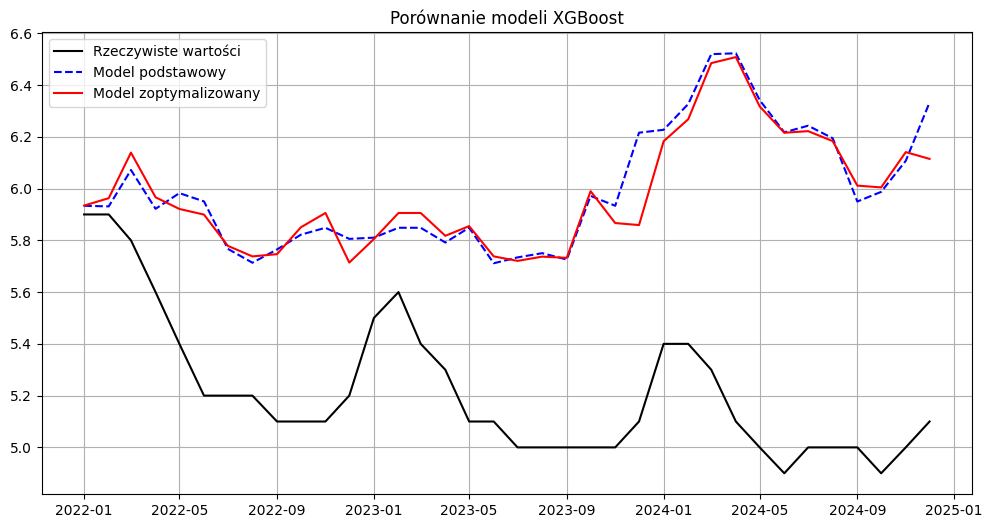

In [35]:
# Porównanie modeli (podstawowego i zoptymalizowanego)
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Rzeczywiste wartości', color='black')
plt.plot(y_test.index, y_pred, label='Model podstawowy', color='blue', linestyle='--')
plt.plot(y_test.index, y_pred_best, label='Model zoptymalizowany', color='red')
plt.title('Porównanie modeli XGBoost')
plt.legend()
plt.grid(True)
plt.show()

### XGBoost - II podejście

In [36]:
def create_features(df, target_col, lag_range=6):
    df_features = df.copy()
    
    # Dodajemy opóźnione wartości dla zmiennej celu (stopa_bezrobocia)
    for i in range(1, lag_range + 1):
        df_features[f'{target_col}_lag{i}'] = df_features[target_col].shift(i)
    
    # Dodajemy opóźnione wartości dla pozostałych zmiennych
    for col in df.columns:
        if col != target_col:
            for i in range(1, lag_range + 1):
                df_features[f'{col}_lag{i}'] = df_features[col].shift(i)
    
    # Dodajemy cechy sezonowe dla danych z indeksem czasowym
    if isinstance(df.index, pd.DatetimeIndex):
        df_features['month'] = df_features.index.month
        df_features['quarter'] = df_features.index.quarter
        df_features['year'] = df_features.index.year
    
    return df_features

# Przygotowanie danych
target_col = 'stopa_bezrobocia'
df_with_features = create_features(df, target_col, lag_range=6)  # Używamy 6 opóźnień
df_with_features = df_with_features.dropna()  # Usuwamy wiersze z NaN

# Podział na cechy i zmienną celu
X = df_with_features.drop(columns=[target_col])
y = df_with_features[target_col]

In [37]:
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Normalizacja danych - to jest kluczowy krok dla poprawy wydajności XGBoost
# Używamy StandardScaler (standaryzacja) do normalizacji cech
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Zachowujemy nazwy kolumn dla późniejszej interpretacji
feature_names = X.columns


Root Mean Squared Error (RMSE): 0.4531
Mean Absolute Error (MAE): 0.4117
R^2 Score: -2.4215


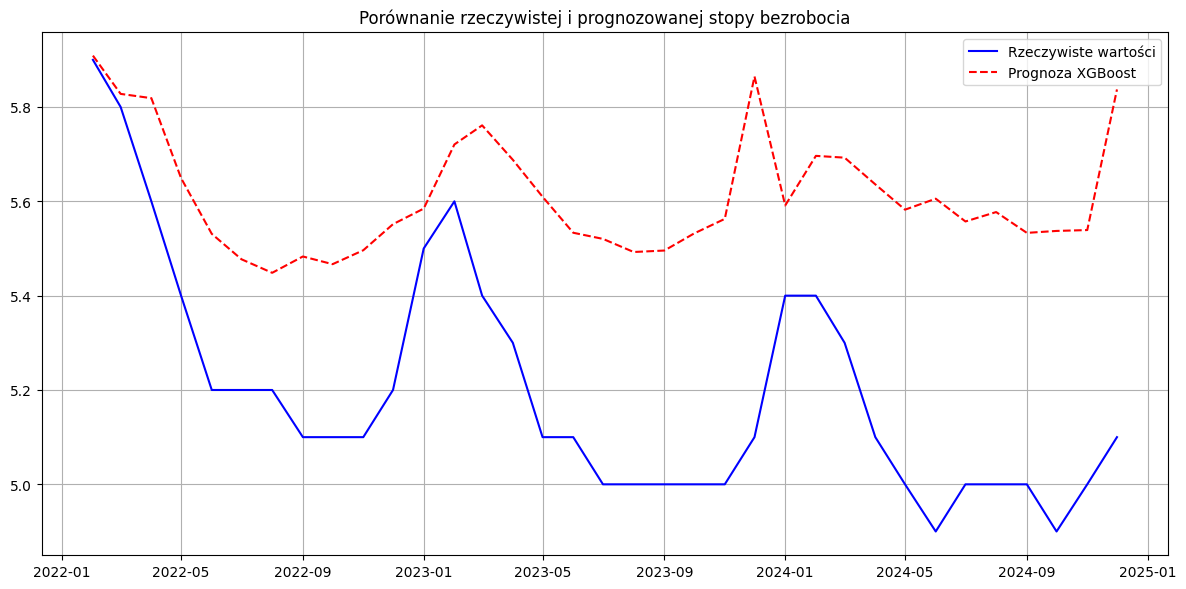

In [38]:
xgb_model = XGBRegressor(
    objective='reg:squarederror', 
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Trenowanie modelu na znormalizowanych danych
xgb_model.fit(X_train_scaled, y_train)

# Predykcja
y_pred = xgb_model.predict(X_test_scaled)

# Ocena modelu
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # RMSE - pierwiastek ze średniego błędu kwadratowego
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R^2 Score: {r2:.4f}")

# Wizualizacja rzeczywistych i prognozowanych wartości
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Rzeczywiste wartości', color='blue')
plt.plot(y_test.index, y_pred, label='Prognoza XGBoost', color='red', linestyle='--')
plt.title('Porównanie rzeczywistej i prognozowanej stopy bezrobocia')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [39]:
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8]
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(objective='reg:squarederror'),
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print(f"Najlepsze parametry: {grid_search.best_params_}")
print(f"Najlepszy wynik: {-grid_search.best_score_}")

# Najlepszy model
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test_scaled)

# Ocena najlepszego modelu
mse_best = mean_squared_error(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"Najlepszy model - MSE: {mse_best}")
print(f"Najlepszy model - MAE: {mae_best}")
print(f"Najlepszy model - R^2: {r2_best}")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Najlepsze parametry: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.7}
Najlepszy wynik: 2.4859405224585536
Najlepszy model - MSE: 0.1367895372986485
Najlepszy model - MAE: 0.3335718754359654
Najlepszy model - R^2: -1.2798256216441413


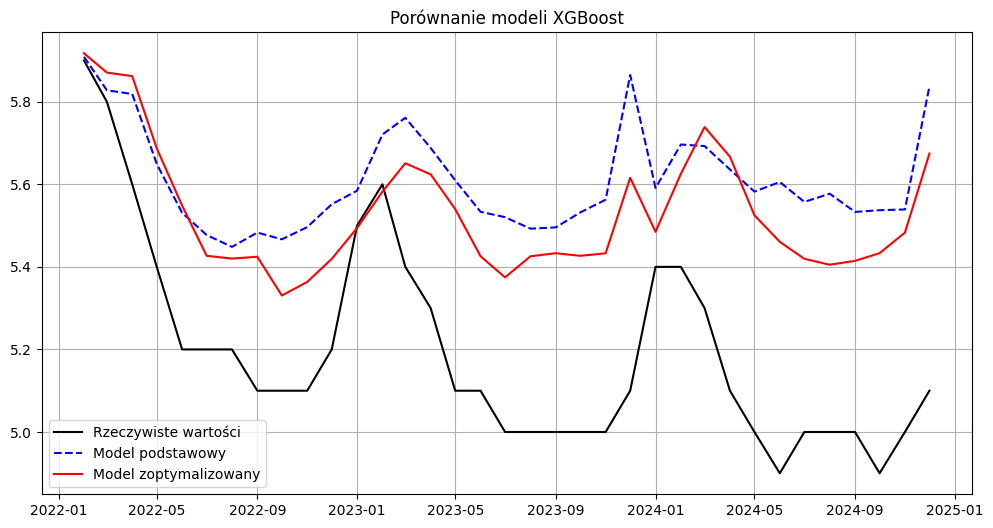

In [40]:
# Porównanie modeli (podstawowego i zoptymalizowanego)
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label='Rzeczywiste wartości', color='black')
plt.plot(y_test.index, y_pred, label='Model podstawowy', color='blue', linestyle='--')
plt.plot(y_test.index, y_pred_best, label='Model zoptymalizowany', color='red')
plt.title('Porównanie modeli XGBoost')
plt.legend()
plt.grid(True)
plt.show()

In [41]:
explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test_scaled)

In [42]:
shap_df = pd.DataFrame(shap_values.values, columns=feature_names)

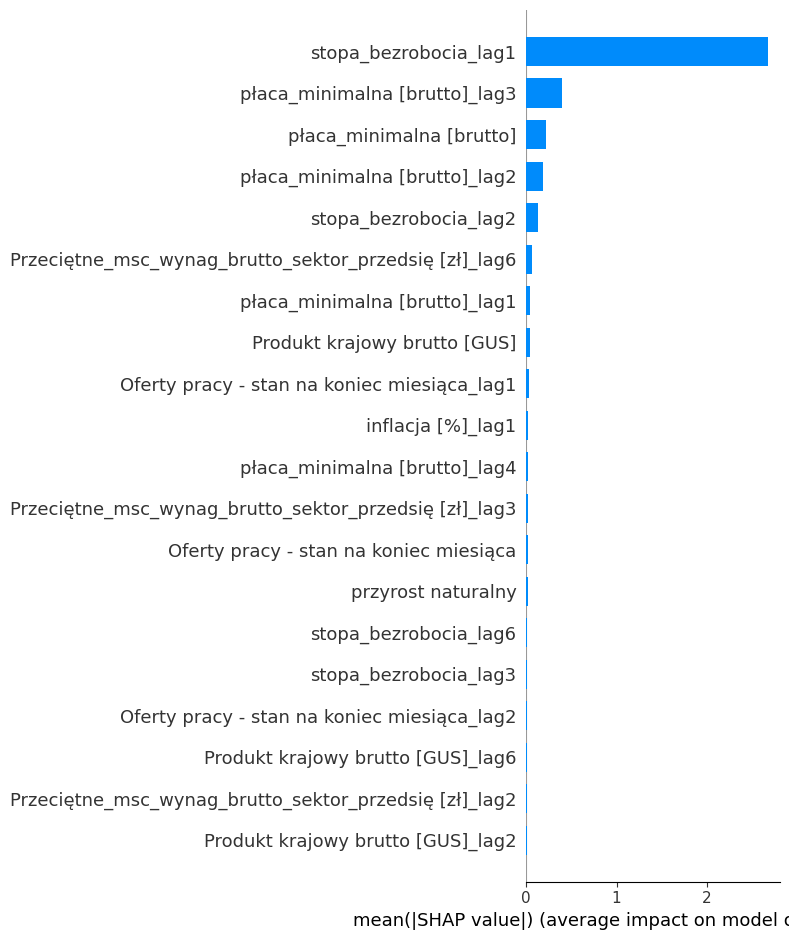

<Figure size 3200x2600 with 0 Axes>

In [48]:
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, plot_type="bar")
plt.gcf().set_size_inches(32, 26)
plt.show()

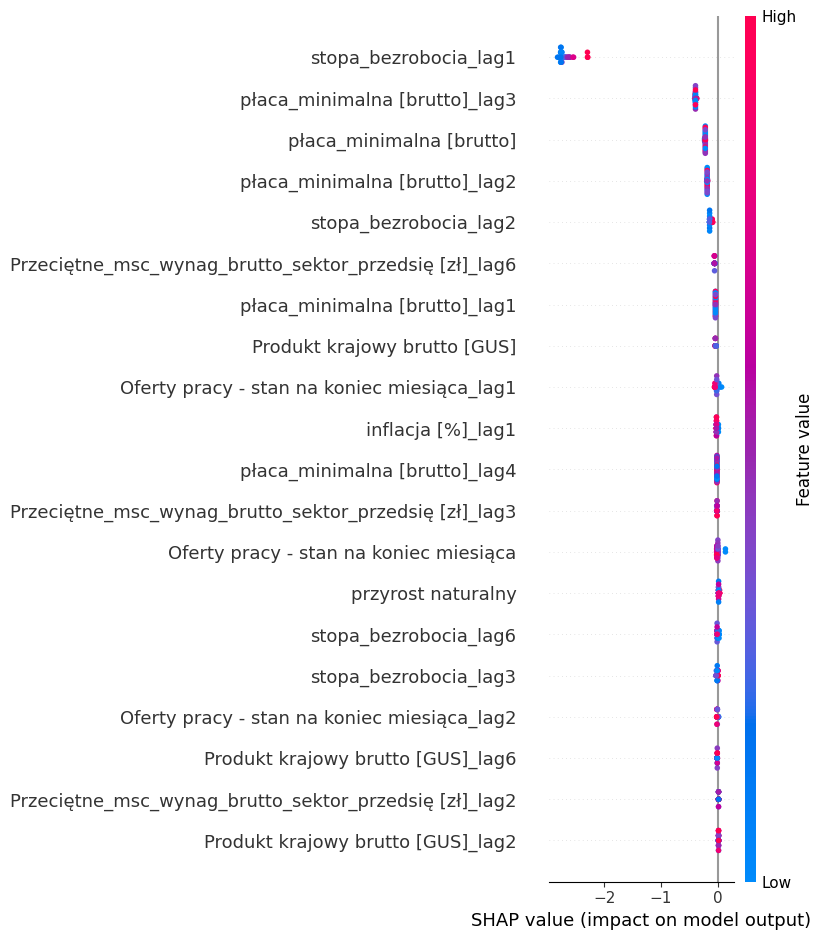

<Figure size 1200x600 with 0 Axes>

In [45]:
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names)

# Zmiana rozmiaru — np. 12 cali szerokości, 6 cali wysokości
plt.gcf().set_size_inches(12, 6)
plt.show()

In [49]:
importance = np.abs(shap_values.values).mean(0)
top_features_idx = importance.argsort()[-5:]  # 5 najważniejszych cech
top_features = [feature_names[i] for i in top_features_idx]

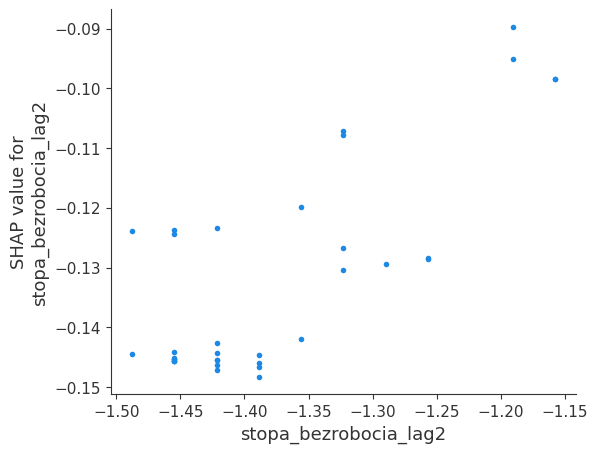

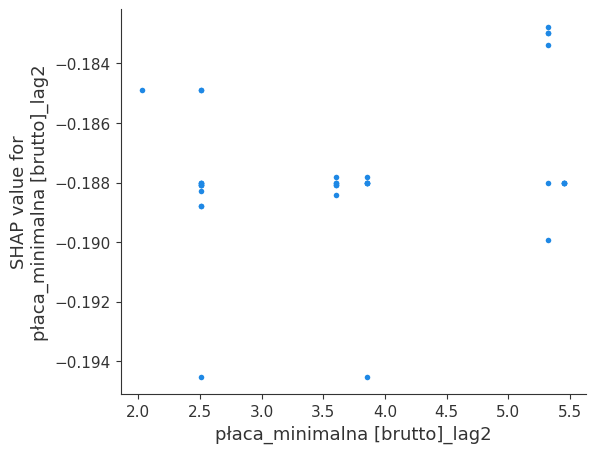

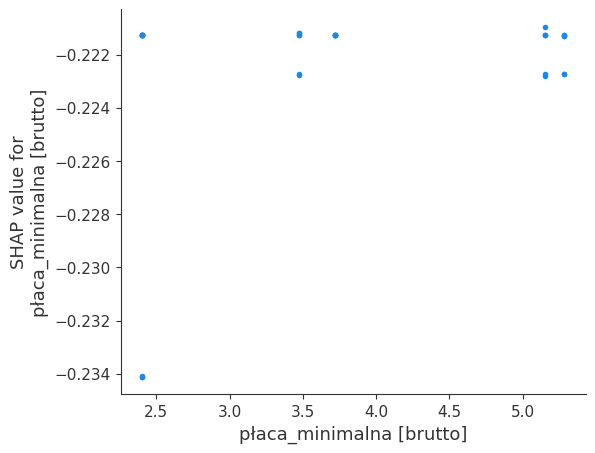

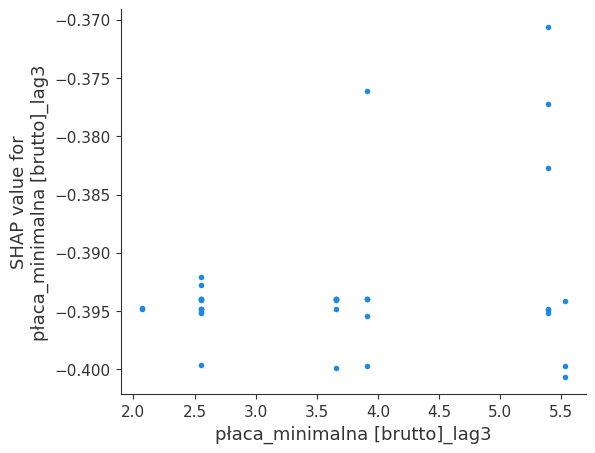

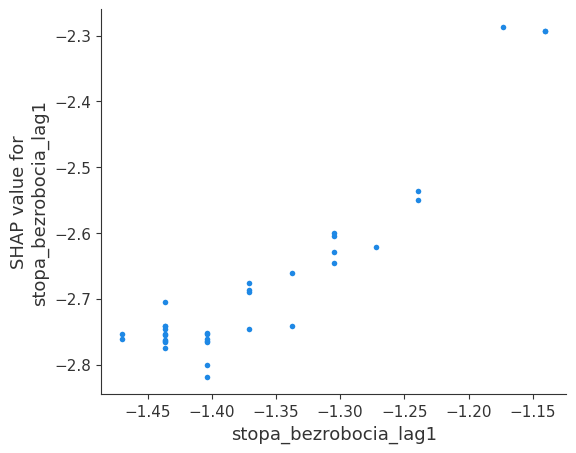

In [50]:
for feature in top_features:
    feature_idx = list(feature_names).index(feature)
    shap.dependence_plot(feature_idx, shap_values.values, X_test_scaled, 
                         feature_names=feature_names, 
                         interaction_index=None)

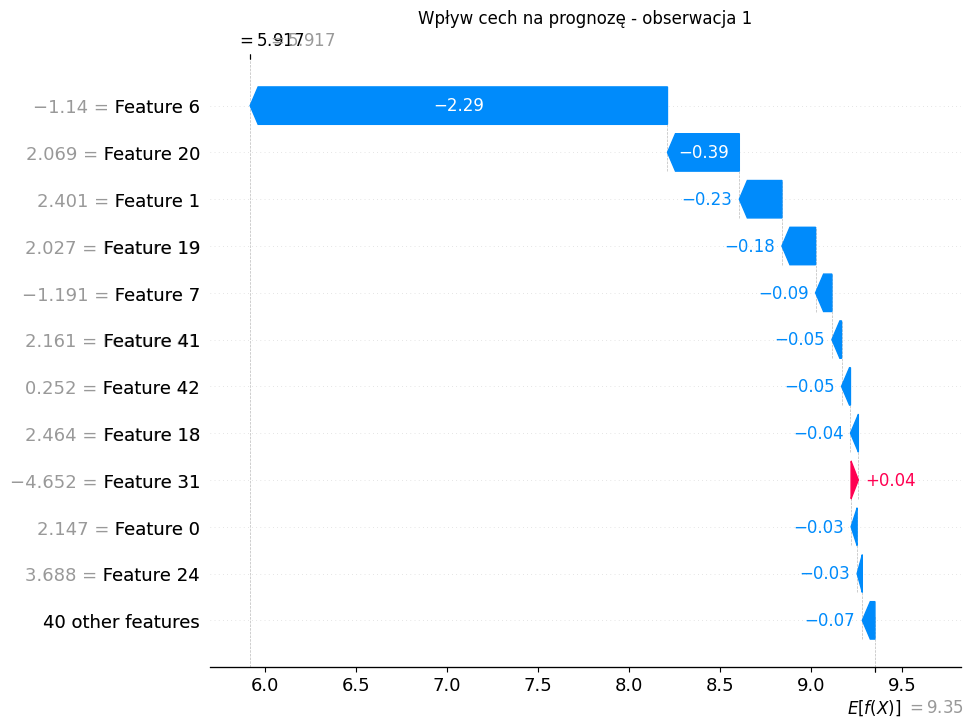

Obserwacja 1 (indeks 0):
Rzeczywista stopa bezrobocia: 5.9000
Prognozowana stopa bezrobocia: 5.9089
Błąd: -0.0089
--------------------------------------------------


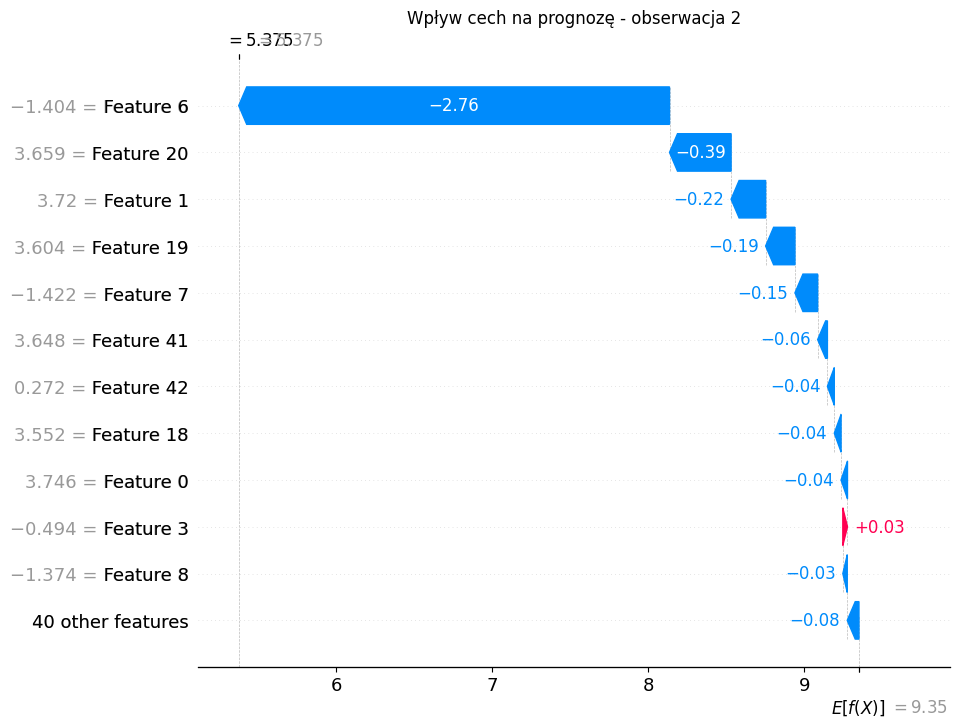

Obserwacja 2 (indeks 17):
Rzeczywista stopa bezrobocia: 5.0000
Prognozowana stopa bezrobocia: 5.5203
Błąd: -0.5203
--------------------------------------------------


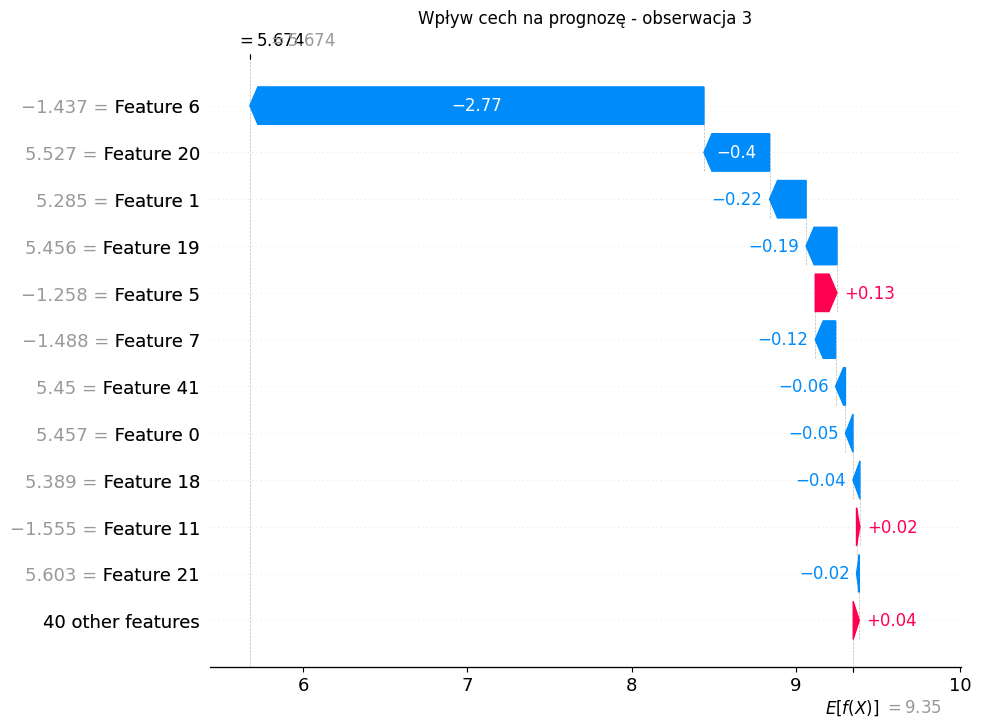

Obserwacja 3 (indeks 34):
Rzeczywista stopa bezrobocia: 5.1000
Prognozowana stopa bezrobocia: 5.8372
Błąd: -0.7372
--------------------------------------------------


In [52]:
n_samples = 3
sample_indices = np.linspace(0, len(X_test_scaled)-1, n_samples, dtype=int)

for i, idx in enumerate(sample_indices):
    plt.figure(figsize=(12, 4))
    plt.title(f"Wpływ cech na prognozę - obserwacja {i+1}")
    plt.tight_layout()
    shap.plots.waterfall(shap_values[idx], max_display=12, show=False)
    plt.show()
    
    # Wyświetlamy rzeczywistą i prognozowaną wartość
    print(f"Obserwacja {i+1} (indeks {idx}):")
    print(f"Rzeczywista stopa bezrobocia: {y_test.iloc[idx]:.4f}")
    print(f"Prognozowana stopa bezrobocia: {y_pred[idx]:.4f}")
    print(f"Błąd: {y_test.iloc[idx] - y_pred[idx]:.4f}")
    print("-" * 50)

In [53]:
# 5. Interakcje między cechami (opcjonalnie, może być obliczeniowo intensywne)
# Obliczamy macierz interakcji SHAP dla 500 losowych próbek (dla wydajności)
# Możesz zwiększyć liczbę próbek dla dokładniejszych wyników
n_interactions = min(500, len(X_test_scaled))
sample_idx = np.random.choice(len(X_test_scaled), n_interactions, replace=False)

print("Obliczanie interakcji SHAP (może zająć chwilę)...")
interaction_values = shap.TreeExplainer(xgb_model).shap_interaction_values(X_test_scaled[sample_idx])

# Sumujemy wartości bezwzględne interakcji
interaction_matrix = np.abs(interaction_values).sum(0)

interaction_df = pd.DataFrame(interaction_matrix, 
                             index=feature_names, 
                             columns=feature_names)

# Wizualizacja najsilniejszych interakcji
plt.figure(figsize=(12, 10))
top_interactions = 10  # Pokazujemy top 10 interakcji
# Tworzymy maskę dla wartości diagonalnych (interakcje cech z samymi sobą)
mask = np.zeros_like(interaction_df.values)
np.fill_diagonal(mask, 1)
masked_interaction_df = interaction_df.mask(mask.astype(bool))

# Spłaszczamy macierz i wybieramy najsilniejsze interakcje
flat_interactions = masked_interaction_df.values.flatten()
top_indices = np.argsort(-flat_interactions)[:top_interactions]
row_indices, col_indices = np.unravel_index(top_indices, interaction_df.shape)

# Tworzymy DataFrame z najsilniejszymi interakcjami
top_interactions_df = pd.DataFrame({
    'Cecha 1': [feature_names[i] for i in row_indices],
    'Cecha 2': [feature_names[i] for i in col_indices],
    'Siła interakcji': flat_interactions[top_indices]
})

print("\nNajsilniejsze interakcje między cechami:")
print(top_interactions_df)

# Interpretacja wyników SHAP - podsumowanie
print("\n===== PODSUMOWANIE ANALIZY SHAP =====")
print("Top 10 najważniejszych cech wg wartości SHAP:")
top10_features_idx = importance.argsort()[-10:][::-1]  # Od najważniejszej do mniej ważnej
for i, idx in enumerate(top10_features_idx):
    print(f"{i+1}. {feature_names[idx]}: {importance[idx]:.4f}")

# Grupowanie cech według typu
lag_features = [f for f in feature_names if '_lag' in f]
original_features = [f for f in feature_names if '_lag' not in f and f not in ['month', 'quarter', 'year']]
seasonal_features = [f for f in feature_names if f in ['month', 'quarter', 'year']]

# Obliczanie średniego znaczenia według grup cech
lag_importance = np.mean([importance[list(feature_names).index(f)] for f in lag_features])
original_importance = np.mean([importance[list(feature_names).index(f)] for f in original_features if f in feature_names])
seasonal_importance = np.mean([importance[list(feature_names).index(f)] for f in seasonal_features if f in feature_names])

print("\nŚrednie znaczenie grup cech:")
print(f"Cechy opóźnione (lag): {lag_importance:.4f}")
print(f"Cechy oryginalne: {original_importance:.4f}")
print(f"Cechy sezonowe: {seasonal_importance:.4f}")

# Dodatkowa analiza dla najważniejszej cechy
most_important_feature = feature_names[importance.argmax()]
print(f"\nNajważniejsza cecha: {most_important_feature}")
print("Szczegółowa analiza tej cechy może pomóc w lepszym zrozumieniu modelu.")

Obliczanie interakcji SHAP (może zająć chwilę)...

Najsilniejsze interakcje między cechami:
                                       Cecha 1  \
0                        stopa_bezrobocia_lag2   
1                płaca_minimalna [brutto]_lag3   
2  Oferty pracy - stan na koniec miesiąca_lag2   
3                        stopa_bezrobocia_lag1   
4                        stopa_bezrobocia_lag1   
5                płaca_minimalna [brutto]_lag3   
6                płaca_minimalna [brutto]_lag3   
7  Oferty pracy - stan na koniec miesiąca_lag1   
8  Oferty pracy - stan na koniec miesiąca_lag2   
9                płaca_minimalna [brutto]_lag3   

                                       Cecha 2  Siła interakcji  
0                płaca_minimalna [brutto]_lag3         1.637734  
1                        stopa_bezrobocia_lag2         1.637734  
2                        stopa_bezrobocia_lag1         1.109480  
3  Oferty pracy - stan na koniec miesiąca_lag2         1.109477  
4                płaca_mini